# Exploratory Data Analysis (EDA) – Sales Dataset
### VEDA Technology | Data Analytics Track | Level 1 – Day 2

**Objective:** Explore the dataset to identify patterns, relationships, outliers, and trends before drawing conclusions.

**Tools:** Python, Pandas, Matplotlib, Seaborn

### Questions explored
1. What does the overall sales/profit distribution look like?
2. Which categories and regions contribute most to sales?
3. Is there a relationship between sales and profit?
4. Are there unusual/outlier sales values?
5. How do sales change over time?

> **Note:** This notebook uses a 1,000-row sales dataset prepared for the EDA task. Missing values and an intentional sales outlier are included so that data-quality checks can be demonstrated.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Load the dataset
df = pd.read_csv("EDA_Sales_Data.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 11)


,Order_ID,Order_Date,Region,Category,Product,Quantity,Unit_Price,Discount,Sales,Profit,Month
0,SO0001,2025-03-13,North,Furniture,Chair,5.0,218.15,0.00,1090.76,143.77,2025-03
1,SO0002,2025-05-11,North,Accessories,USB Hub,6.0,76.32,0.15,389.22,83.45,2025-05
2,SO0003,2025-11-10,North,Electronics,Headphones,6.0,194.63,0.00,1167.76,234.86,2025-11
3,SO0004,2025-06-24,South,Accessories,Webcam,3.0,77.35,0.05,220.45,48.23,2025-06
4,SO0005,2025-06-16,North,Accessories,Webcam,2.0,65.10,0.00,130.19,32.96,2025-06


## 1. Data Quality Check

In [2]:
# Structure, data types, missing values and duplicates
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Data types:


Order_ID              object
Order_Date    datetime64[ns]
Region                object
Category              object
Product               object
Quantity             float64
Unit_Price           float64
Discount             float64
Sales                float64
Profit               float64
Month                 object
dtype: object


Missing values:


,Missing_Count
Discount,3
Unit_Price,2
Quantity,2
Region,0
Order_Date,0
Order_ID,0
Product,0
Category,0
Sales,0
Profit,0



Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_ID,1000,1000,SO0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,1000,NaN,NaN,NaN,2025-07-07 09:40:19.200000256,2025-01-01 00:00:00,2025-04-03 00:00:00,2025-07-09 12:00:00,2025-10-10 00:00:00,2025-12-31 00:00:00,NaN
Region,1000,4,North,303,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1000,4,Electronics,314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1000,16,Headphones,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,998.0,NaN,NaN,NaN,5.579158,1.0,3.0,6.0,8.0,10.0,2.909406
Unit_Price,998.0,NaN,NaN,NaN,210.127946,12.91,63.6125,167.92,339.6175,665.51,167.10975
Discount,997.0,NaN,NaN,NaN,0.064895,0.0,0.0,0.05,0.1,0.2,0.062666
Sales,1000.0,NaN,NaN,NaN,1112.91384,20.92,283.6375,612.23,1693.16,5889.62,1147.515025
Profit,1000.0,NaN,NaN,NaN,196.88576,5.78,61.185,121.49,249.3075,1476.31,205.939707


**Observation:** The dataset contains 1,000 sales records. A few missing values are present in `Discount`, `Unit_Price`, and `Quantity`, so these fields should be handled before modeling or final reporting. The duplicate check helps confirm whether repeated complete rows exist.

## 2. Correlation Heatmap
**Question:** Which numerical variables move together?

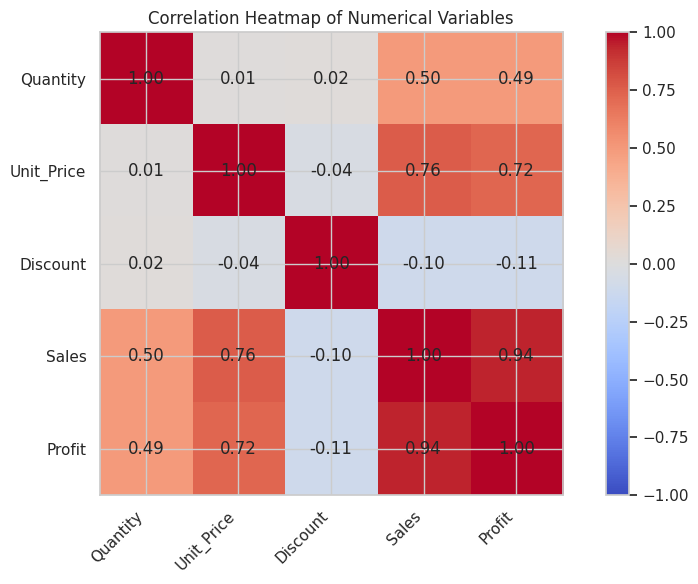

In [3]:
numeric_cols = ["Quantity", "Unit_Price", "Discount", "Sales", "Profit"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

**Observation:** Sales has a strong positive relationship with Quantity because larger quantities generally create larger order values. Profit also tends to rise with Sales, while Discount shows a weaker relationship with the other variables. Correlation indicates association, not causation.

## 3. Sales Distribution
**Question:** How are order sales distributed, and are there extreme values?

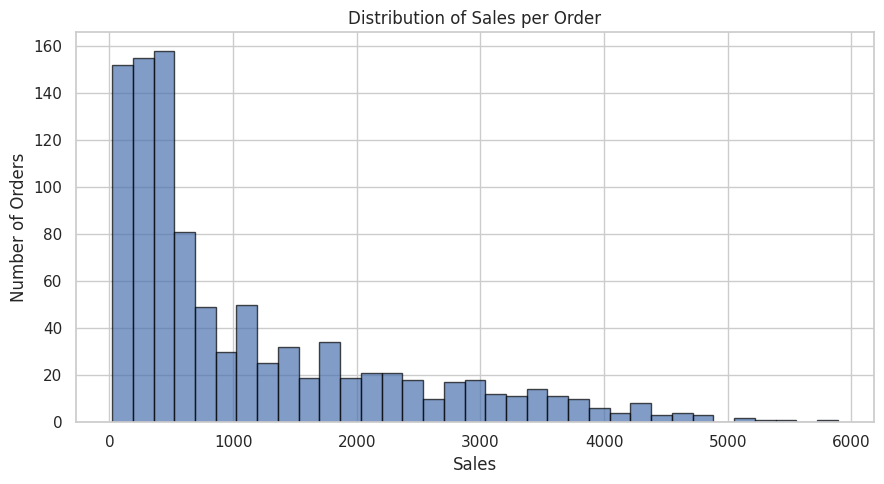

In [4]:
plt.figure(figsize=(9, 5))
plt.hist(df["Sales"].dropna(), bins=35, edgecolor="black", alpha=0.7)
plt.title("Distribution of Sales per Order")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

**Observation:** Most orders are concentrated in the lower-to-middle sales range, with a long right tail. A small number of orders have much higher sales values than typical orders, suggesting potential outliers.

## 4. Boxplot for Outliers
**Question:** Which categories contain unusually high sales values?

<Figure size 1000x600 with 0 Axes>

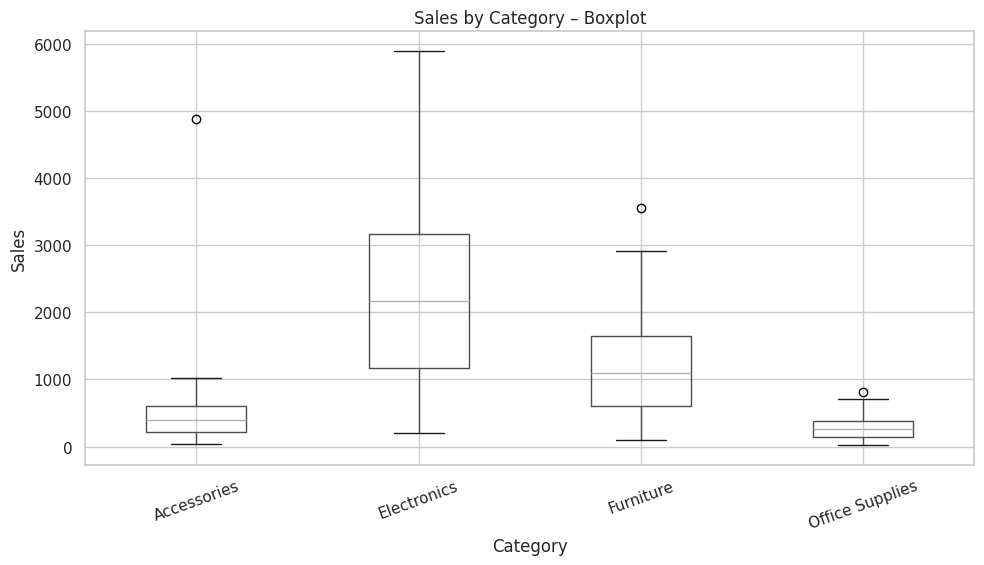

In [5]:
plt.figure(figsize=(10, 6))
df.boxplot(column="Sales", by="Category", figsize=(10, 6))
plt.suptitle("")
plt.title("Sales by Category – Boxplot")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Observation:** The boxplot shows the spread of sales across categories and makes unusually high observations easy to identify. Electronics generally has higher order values, while Office Supplies has a lower typical sales range. Extreme points should be investigated rather than automatically deleted.

## 5. Category Sales Comparison
**Question:** Which product categories generate the most total sales?

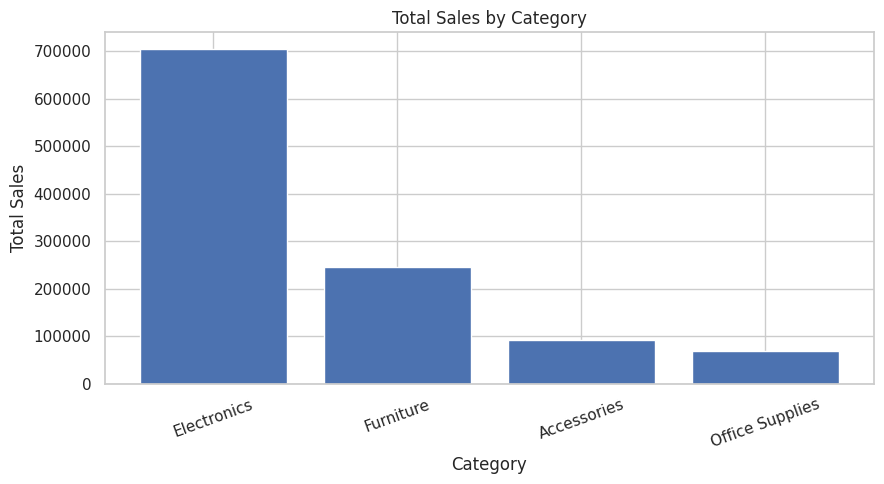

,Category,Sales
1,Electronics,704982.91
2,Furniture,246091.83
0,Accessories,92323.45
3,Office Supplies,69515.65


In [6]:
category_sales = df.groupby("Category", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(category_sales["Category"], category_sales["Sales"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(category_sales)

**Observation:** The category totals show that sales contribution is not evenly distributed. Electronics contributes a large share of total sales because its average order value is higher, while lower-priced categories generate smaller order totals.

## 6. Sales Trend Over Time
**Question:** How does monthly sales performance change during the year?

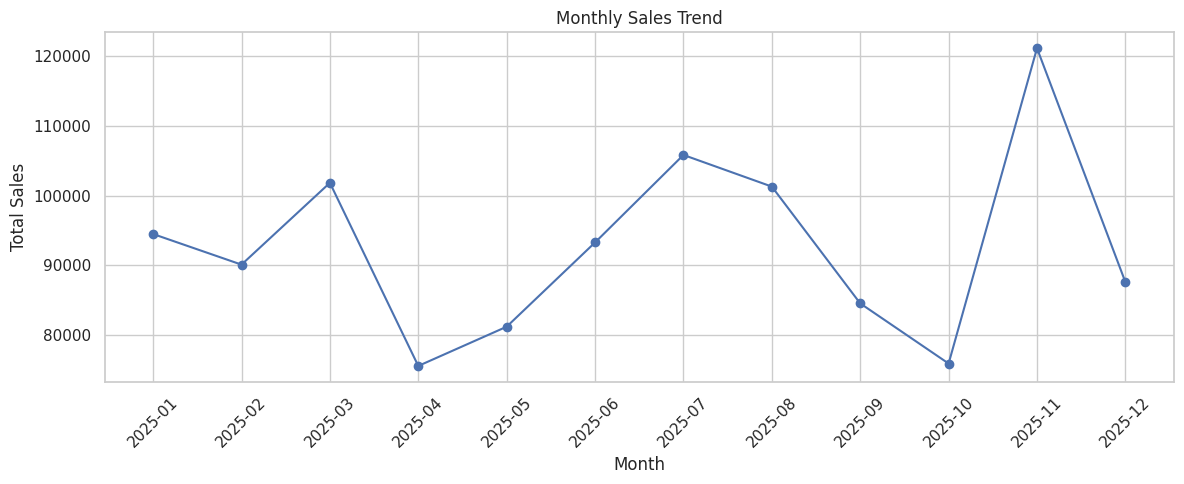

In [7]:
monthly_sales = df.groupby("Month", as_index=False)["Sales"].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["Month"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Monthly sales fluctuate throughout the year rather than remaining constant. Peaks and dips can be investigated further by checking region, category, quantity, discounts, or individual large orders for the months with unusual performance.

## 7. Sales vs Profit Relationship
**Question:** Do higher-sales orders generally generate higher profit?

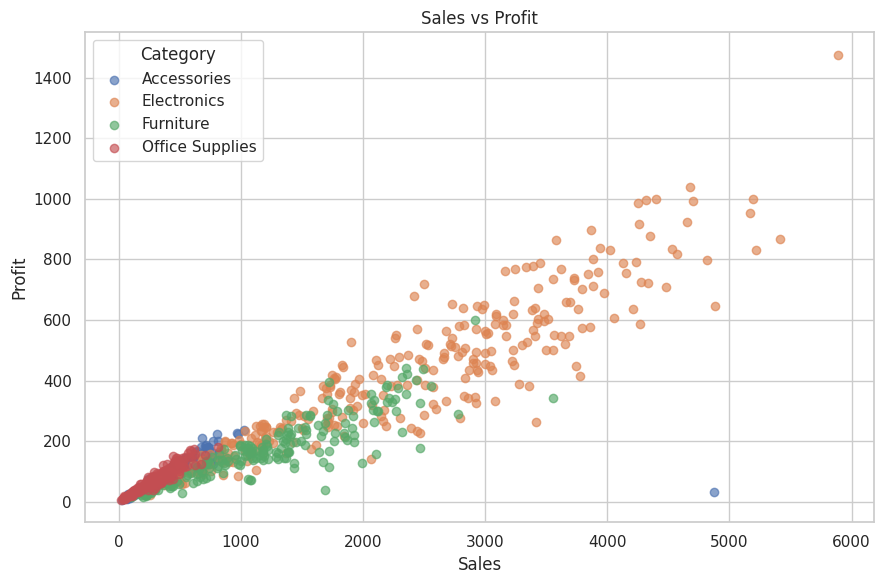

In [8]:
plt.figure(figsize=(9, 6))
for cat, g in df.groupby("Category"):
    plt.scatter(g["Sales"], g["Profit"], alpha=0.65, label=cat)
plt.legend(title="Category")
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

**Observation:** Profit generally increases as Sales increases, although individual orders vary. The scatterplot also shows that category-level pricing and margins influence where observations appear. Very unusual points should be checked before using the data for business decisions.

## 8. Regional Summary

In [9]:
region_summary = df.groupby("Region").agg(
    Orders=("Order_ID", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Avg_Order_Sales=("Sales", "mean")
).sort_values("Total_Sales", ascending=False)

display(region_summary.round(2))

,Orders,Total_Sales,Total_Profit,Avg_Order_Sales
Region,,,,
North,303,342183.51,60144.55,1129.32
West,231,271476.51,49245.50,1175.22
South,244,249862.46,42746.12,1024.03
East,222,249391.36,44749.59,1123.38


## Top 3 Insights

1. **Category contribution:** Sales are concentrated more heavily in higher-value categories, especially Electronics, rather than being evenly distributed.
2. **Outliers and data quality:** The sales distribution has a right tail and the boxplot highlights unusually large orders. Missing values also need treatment before deeper analysis.
3. **Sales and profit relationship:** Higher sales are generally associated with higher profit, but the relationship is not perfectly linear because category, discount, quantity, and pricing also affect profit.

### Conclusion
EDA shows why summary statistics and visual checks should come before conclusions. The next step would be to clean missing values, investigate the identified outlier(s), and then build a dashboard or deeper analysis.